#  Level 3 — Task 3: Neural Networks with TensorFlow/Keras
**Intern:** Amos Njama Mungai | **Company:** Codveda Technologies

**Dataset:** Iris Dataset (1) iris.csv)

**Objectives:**
- Load and preprocess the dataset
- Design a neural network architecture (input, hidden, output layers)
- Train the model using backpropagation
- Evaluate using accuracy and visualize training/validation loss

**Tools:** Python, TensorFlow/Keras, Pandas, Matplotlib

## Step 1: Mount Google Drive

In [22]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted successfully')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully


## Step 2: Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)

print(f'✅ TensorFlow version: {tf.__version__}')
print('✅ All libraries imported successfully')

✅ TensorFlow version: 2.20.0
✅ All libraries imported successfully


## Step 3: Load the Dataset

In [24]:
df = pd.read_csv('/content/drive/MyDrive/Data Set For Task/1) iris.csv')
print('✅ Dataset loaded successfully')
print(f'Shape: {df.shape}')
df.head(10)

✅ Dataset loaded successfully
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## Step 4: Explore & Preprocess

In [25]:
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Class Distribution ===')
print(df['species'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

=== Missing Values ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

=== Class Distribution ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [26]:
# Features and target
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = df[features].values

# Label encode
le = LabelEncoder()
y_encoded = le.fit_transform(df['species'])
print('Classes:', le.classes_)
print('Encoded:', np.unique(y_encoded))

# One-hot encode for neural network output layer
y_onehot = to_categorical(y_encoded, num_classes=3)
print(f'\ny shape after one-hot encoding: {y_onehot.shape}')
print('Example:', y_onehot[:3])

Classes: ['setosa' 'versicolor' 'virginica']
Encoded: [0 1 2]

y shape after one-hot encoding: (150, 3)
Example: [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [27]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Validation/Test split — 70% / 15% / 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_onehot, test_size=0.3, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f'Training samples   : {len(X_train)}')
print(f'Validation samples : {len(X_val)}')
print(f'Testing samples    : {len(X_test)}')

Training samples   : 105
Validation samples : 22
Testing samples    : 23


## Step 5: Design the Neural Network Architecture

In [28]:
tf.random.set_seed(42)

model = keras.Sequential([
    # Input layer
    layers.Input(shape=(4,), name='Input_Layer'),

    # Hidden Layer 1
    layers.Dense(64, activation='relu', name='Hidden_Layer_1'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Hidden Layer 2
    layers.Dense(32, activation='relu', name='Hidden_Layer_2'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # Hidden Layer 3
    layers.Dense(16, activation='relu', name='Hidden_Layer_3'),

    # Output layer — 3 classes (softmax)
    layers.Dense(3, activation='softmax', name='Output_Layer')
], name='Iris_Neural_Network')

model.summary()

Model: "Iris_Neural_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,363 (13.14 KB)

 Trainable params: 3,171 (12.39 KB)

 Non-trainable params: 192 (768.00 B)

## Step 6: Compile the Model

In [29]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('✅ Model compiled successfully')
print('  Optimizer : Adam (lr=0.001)')
print('  Loss      : Categorical Crossentropy')
print('  Metrics   : Accuracy')

✅ Model compiled successfully
  Optimizer : Adam (lr=0.001)
  Loss      : Categorical Crossentropy
  Metrics   : Accuracy


## Step 7: Train the Model (Backpropagation)

In [30]:
# Early stopping to prevent overfitting
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

print(f'\n✅ Training complete — Stopped at epoch {len(history.history["loss"])}')

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.4095 - loss: 1.5037 - val_accuracy: 0.2273 - val_loss: 1.0524
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4952 - loss: 1.1507 - val_accuracy: 0.7273 - val_loss: 0.9905
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6000 - loss: 0.8408 - val_accuracy: 0.7273 - val_loss: 0.9420
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6952 - loss: 0.7278 - val_accuracy: 0.7273 - val_loss: 0.8990
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8000 - loss: 0.5363 - val_accuracy: 0.7273 - val_loss: 0.8622
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8571 - loss: 0.4443 - val_accuracy: 0.7273 - val_loss: 0.8273
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9048 - loss: 0.3802 - val_accuracy: 0.7273 - val_loss: 0.7952
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8762 - loss: 0.3872 - val_accuracy: 0.7273 - val_loss:

## Step 8: Visualize Training & Validation Loss

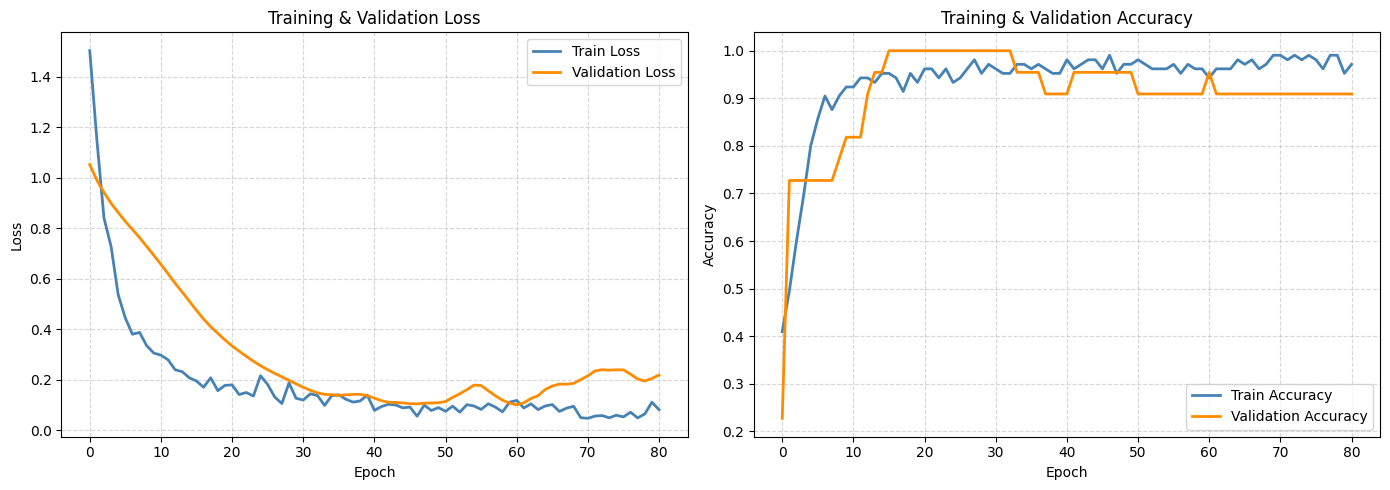

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'],     label='Train Loss',      color='steelblue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2)
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Accuracy plot
axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linewidth=2)
axes[1].set_title('Training & Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Step 9: Evaluate the Model on Test Set

In [32]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

f1 = f1_score(y_true, y_pred, average='weighted')

print('=======================================')
print('       NEURAL NETWORK EVALUATION')
print('=======================================')
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_accuracy*100:.2f}%')
print(f'  F1-Score      : {f1*100:.2f}%')
print('=======================================')
print()
print('=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=le.classes_))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
       NEURAL NETWORK EVALUATION
  Test Loss     : 0.0795
  Test Accuracy : 95.65%
  F1-Score      : 95.62%

=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         6
  versicolor       1.00      0.88      0.93         8
   virginica       0.90      1.00      0.95         9

    accuracy                           0.96        23
   macro avg       0.97      0.96      0.96        23
weighted avg       0.96      0.96      0.96        23



## Step 10: Confusion Matrix

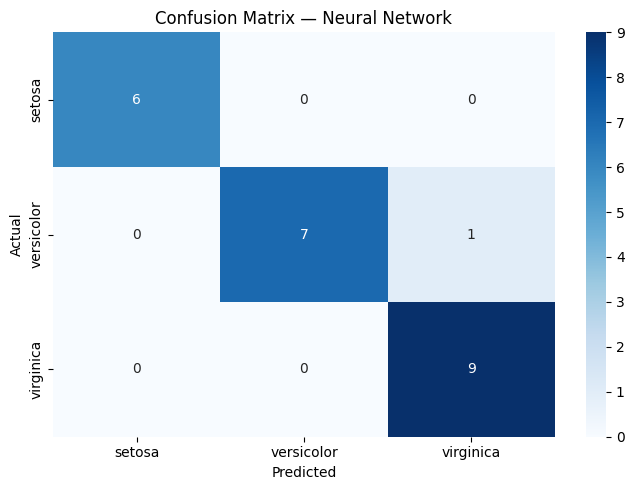

In [33]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()